In [2]:
from qiskit.circuit import QuantumCircuit, QuantumRegister, AncillaRegister
from qiskit.quantum_info import Statevector, Operator

import matplotlib.pyplot as plt

import numpy as np
import math

# strategy:

- nbits = ceil(log2(N))
- registers are all empty slots in sudoku 
- flag ancillas: 1 for each row, column, box = 3*N. 
- scratch ancillas: nbits to compare numbers
- All-Different oracle: a gate that flips phase if all inputs are different

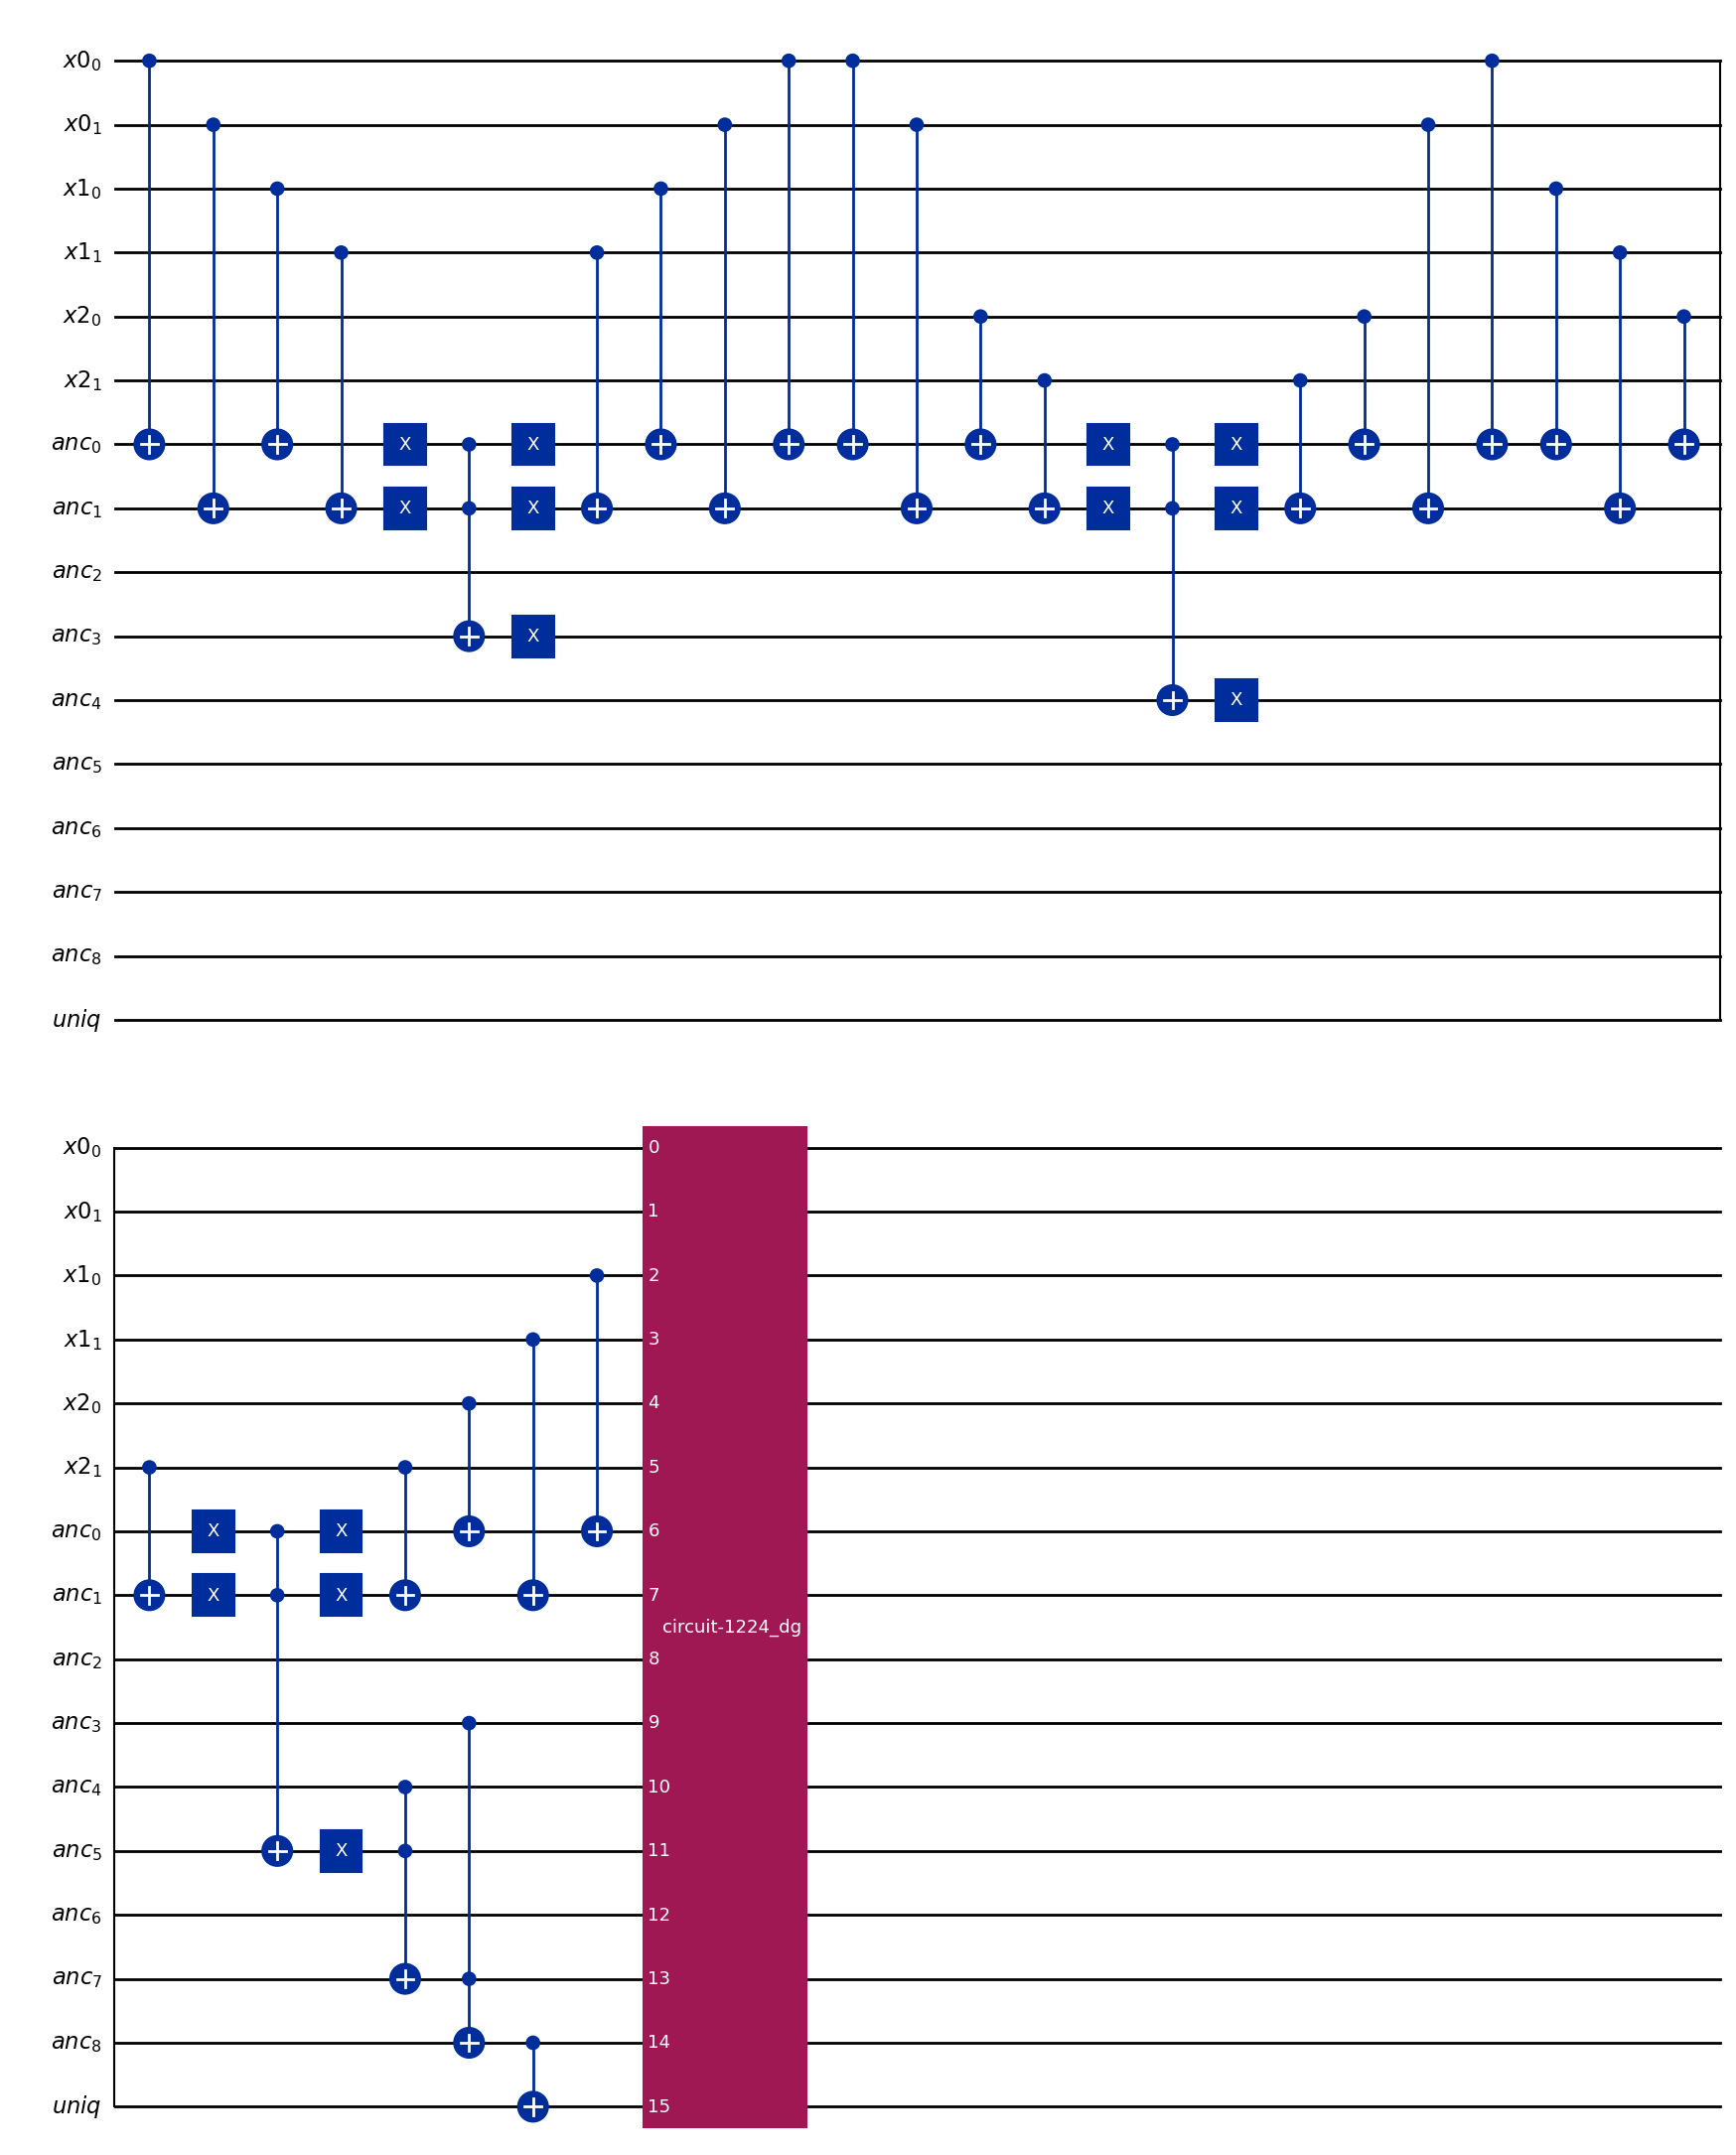

In [327]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import MCXGate

def compare_nbit(qc, reg1, reg2, ancillas, anc_start, flag_qubit):
    """
    Compare two n-qubit registers reg1, reg2:
    - Use ancillas[anc_start : anc_start+n] for bitwise XNORs
    - Write the final equality flag into flag_qubit
    - Uncompute ancillas
    """
    n = len(reg1)
    # 1) bitwise XNOR into ancillas
    for i in range(n):
        a = ancillas[anc_start + i]
        qc.cx(reg1[i], a)
        qc.cx(reg2[i], a)
        qc.x(a)                  # now a = 1 iff reg1[i] == reg2[i]

    # 2) AND all those ancillas down to one flag via a small CCX tree
    #    Here n=2 so just one CCX; for larger n you'd build a tree similarly.
    if n == 1:
        qc.cx(ancillas[anc_start], flag_qubit)
    elif n == 2:
        qc.ccx(ancillas[anc_start], ancillas[anc_start+1], flag_qubit)
    else:
        # build a binary-tree of Toffolis into intermediate ancillas...
        raise NotImplementedError("Extend to n>2 by chaining CCX into more ancillas")

    # 3) uncompute the bitwise XNORs
    for i in reversed(range(n)):
        a = ancillas[anc_start + i]
        qc.x(a)
        qc.cx(reg2[i], a)
        qc.cx(reg1[i], a)


def all_different_oracle_circuit(regs, ancillas, unique):
    """
    regs: list of QuantumRegisters (each n qubits)
    qc:   QuantumCircuit that already contains regs plus ancillas, uniq
    """
    m = len(regs)
    n = len(regs[0])
    assert(len(ancillas)>=2*math.comb(m, 2)+ n+1)
    # ancillas = qc.qregs[-2]  # assume second-to-last register is ancillas
    # uniq      = qc.qregs[-1][0]  # last register is uniq (1 qubit)

    qc = QuantumCircuit(*regs, ancillas, unique)
    comp_flags = []
    anc_ptr = math.comb(m, 2)  # pointer into ancillas

    # 1) Pairwise comparisons
    for i in range(m):
        for j in range(i+1, m):
            # pick one ancilla qubit to hold the equality flag
            flag = ancillas[anc_ptr]
            anc_ptr += 1
            comp_flags.append(flag)

            # compare regs[i] vs regs[j], using next n ancillas
            compare_nbit(qc, regs[i], regs[j], ancillas, 0, flag)
            qc.x(flag)
            # qc.barrier()
            # anc_ptr += 1
    # print(anc_ptr)
    # 2) OR-reduce comp_flags into one "dup" qubit via OR(p,q) = ¬(¬p ∧ ¬q)
    dup = ancillas[anc_ptr]
    anc_ptr += 1
    or_ptr = anc_ptr

    or_controls = comp_flags.copy()
    while len(or_controls) > 1:
        p = or_controls.pop()
        q = or_controls.pop()
        # print(or_ptr)
        tgt = ancillas[or_ptr]
        
        # OR step:
        # qc.x(p); qc.x(q)
        qc.ccx(p, q, tgt)
        # qc.x(p); qc.x(q)
        or_controls.append(tgt)
        or_ptr += 1
    or_ptr -= 1
    # 3) Invert duplicate flag into uniq
    # qc.x(or_controls[0])
    # gate = qc.to_gate()
    first_half = qc.copy()
    
    qc.cx(or_controls[0], unique)
    # qc.x(or_controls[0])
    qc.append(first_half.inverse(), qc.qubits)
    return qc

    




# 3 registers of 2 qubits each
regs = [ QuantumRegister(2, f'x{i}') for i in range(3) ]
m = len(regs)
n = len(regs[0])
ancillas = QuantumRegister(2*math.comb(m, 2)+ n+1, 'anc')  # plenty of scratch
uniq     = QuantumRegister(1,  'uniq')

qc = QuantumCircuit(*regs, ancillas, uniq)

# Build the oracle
all_different_oracle(regs, ancillas, uniq, qc)

# Draw to verify no IndexError
# print(qc)
qc.draw('mpl')


In [46]:
qc_diff.compose?

Signature:
qc_diff.compose(
    other: "Union['QuantumCircuit', Instruction]",
    qubits: 'QubitSpecifier | Sequence[QubitSpecifier] | None' = None,
    clbits: 'ClbitSpecifier | Sequence[ClbitSpecifier] | None' = None,
    front: 'bool' = False,
    inplace: 'bool' = False,
    wrap: 'bool' = False,
    *,
    copy: 'bool' = True,
    var_remap: 'Mapping[str | expr.Var | expr.Stretch, str | expr.Var | expr.Stretch] | None' = None,
    inline_captures: 'bool' = False,
) -> "Optional['QuantumCircuit']"
Docstring:
Apply the instructions from one circuit onto specified qubits and/or clbits on another.

.. note::

    By default, this creates a new circuit object, leaving ``self`` untouched.  For most
    uses of this function, it is far more efficient to set ``inplace=True`` and modify the
    base circuit in-place.

When dealing with realtime variables (:class:`.expr.Var` instances), there are two principal
strategies for using :meth:`compose`:

1. The ``other`` circuit is treated as en

In [3]:
qc_diff.inverse().draw()

NameError: name 'qc_diff' is not defined

In [5]:
print(ancillas)

QuantumRegister(9, 'anc')


In [37]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

# --- (Re-import your oracle code here) ---
# compare_nbit(...)
# all_different_oracle(...)

def make_test_circuit(values):
    """
    values: list of three integers in [0..3], the contents of each 2-bit register
    """
    # 3 registers x0,x1,x2 of 2 qubits each
    regs = [ QuantumRegister(2, f'x{i}') for i in range(3) ]
    ancillas = QuantumRegister(12, 'anc')
    uniq     = QuantumRegister(1,  'uniq')
    # cbit     = ClassicalRegister(1, 'c_uniq')
    # qc = QuantumCircuit(*regs, ancillas, uniq, cbit)
    qc = QuantumCircuit(*regs, ancillas, uniq)
    
    # 1) Initialize each x-register to the desired value
    for i, val in enumerate(values):
        b0 = (val >> 0) & 1
        b1 = (val >> 1) & 1
        if b0:
            qc.x(regs[i][0])
        if b1:
            qc.x(regs[i][1])
    
    # 2) Apply the all-different oracle
    all_different_oracle(regs, ancillas, uniq, qc)
    
    # 3) Measure uniq
    # qc.measure(uniq[0], cbit[0])
    return qc

# --- Example 1: all different [1, 2, 3] → uniq should be 1 ---
qc_diff = make_test_circuit([1, 2, 3])

# --- Example 2: all the same [2, 2, 2] → uniq should be 0 ---
qc_same = make_test_circuit([2, 2, 2])

# --- Run both on the simulator ---
# backend = Aer.get_backend('aer_simulator')
# job = execute([qc_diff, qc_same], backend, shots=1024)
# counts_diff, counts_same = job.result().get_counts(qc_diff), job.result().get_counts(qc_same)
# print("All different [1,2,3] →", counts_diff)
# print("All same      [2,2,2] →", counts_same)

psi = Statevector(qc_diff)
print(str(psi))
print(psi.probabilities())
print_nonzero(psi)

psi = Statevector(qc_same)
print(str(psi))
print(psi.probabilities())

print_nonzero(psi)
qc_diff.draw()

Statevector([0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2))
[0. 0. 0. ... 0. 0. 0.]


NameError: name 'print_nonzero' is not defined

In [88]:
Statevector?

Init signature:
Statevector(
    data: 'np.ndarray | list | Statevector | Operator | QuantumCircuit | circuit.instruction.Instruction',
    dims: 'int | tuple | list | None' = None,
)
Docstring:      Statevector class
Init docstring:
Initialize a statevector object.

Args:
    data: Data from which the statevector can be constructed. This can be either a complex
        vector, another statevector, a ``Operator`` with only one column or a
        ``QuantumCircuit`` or ``Instruction``.  If the data is a circuit or instruction,
        the statevector is constructed by assuming that all qubits are initialized to the
        zero state.
    dims: The subsystem dimension of the state (See additional information).

Raises:
    QiskitError: if input data is not valid.

Additional Information:
    The ``dims`` kwarg can be None, an integer, or an iterable of
    integers.

    * ``Iterable`` -- the subsystem dimensions are the values in the list
      with the total number of subsystems given

In [107]:
QuantumCircuit?

Init signature:
QuantumCircuit(
    *regs: 'Register | int | Sequence[Bit]',
    name: 'str | None' = None,
    global_phase: 'ParameterValueType' = 0,
    metadata: 'dict | None' = None,
    inputs: 'Iterable[expr.Var]' = (),
    captures: 'Iterable[expr.Var | expr.Stretch]' = (),
    declarations: 'Mapping[expr.Var, expr.Expr] | Iterable[Tuple[expr.Var, expr.Expr]]' = (),
)
Docstring:     
Core Qiskit representation of a quantum circuit.

.. note::
    For more details setting the :class:`QuantumCircuit` in context of all of the data
    structures that go with it, how it fits into the rest of the :mod:`qiskit` package, and the
    different regimes of quantum-circuit descriptions in Qiskit, see the module-level
    documentation of :mod:`qiskit.circuit`.

Circuit attributes

:class:`QuantumCircuit` has a small number of public attributes, which are mostly older
functionality.  Most of its functionality is accessed through methods.

A small handful of the attributes are intentionally

In [38]:
def init_qbits(qc, regs, values):
    for i, val in enumerate(values):
        b0 = (val >> 0) & 1
        b1 = (val >> 1) & 1
        if b0:
            qc.x(regs[i][0])
        if b1:
            qc.x(regs[i][1])
def make_init(values, n_ancillas):
    """
    values: list of three integers in [0..3], the contents of each 2-bit register
    """
    # 3 registers x0,x1,x2 of 2 qubits each
    regs = [ QuantumRegister(int(np.ceil(np.log2(np.max(values)+1))), f'x{i}') for i in range(len(values)) ]
    print(regs)
    ancillas = QuantumRegister(n_ancillas, 'anc')
    uniq     = QuantumRegister(1,  'uniq')
    # cbit     = ClassicalRegister(1, 'c_uniq')
    # qc = QuantumCircuit(*regs, ancillas, uniq, cbit)
    qc = QuantumCircuit(*regs, ancillas, uniq)
    
    # 1) Initialize each x-register to the desired value
    for i, val in enumerate(values):
        b0 = (val >> 0) & 1
        b1 = (val >> 1) & 1
        if b0:
            qc.x(regs[i][0])
        if b1:
            qc.x(regs[i][1])
    
    # 2) Apply the all-different oracle
    # all_different_oracle(regs, qc)
    
    # 3) Measure uniq
    # qc.measure(uniq[0], cbit[0])
    return qc, regs, ancillas, uniq

In [39]:
from qiskit.quantum_info import Statevector

def print_nonzero(state: Statevector, tol: float = 1e-10):
    """
    Print only the non-zero components of `state` in the computational basis.
    
    Args:
      state: a Statevector instance
      tol: any amplitude with |amp| <= tol is treated as zero
    """
    data = state.data
    n = state.num_qubits
    for idx, amp in enumerate(data):
        if abs(amp) > tol:
            bitstr = format(idx, f'0{n}b')
            print(f"|{bitstr}>: {amp}")


In [149]:
values=[2, 2]
qc_diff, regs, ancillas, uniq = make_init(values)
qc_diff.cbit

compare_nbit(qc_diff, regs[0], regs[1], ancillas, 0, uniq)
init_qbits(qc_diff, regs, values)
psi = Statevector(qc_diff)
print(str(psi))
print(psi.probabilities())
qc_diff.draw()
qc_diff.measure(uniq)

TypeError: make_init() missing 1 required positional argument: 'n_ancillas'

In [159]:
print_nonzero(psi)

|0111100000101000>: (1+0j)


In [66]:
values=[2,1,1]
qc_diff, regs, ancillas, uniq = make_init(values, n_ancillas=2*math.comb(m, 2)+ n+1)
# qc_diff.x(uniq)

# all_different_oracle(regs, ancillas, uniq, qc_diff)#(regs, ancillas, unique, qc)
qc_diff.compose(all_different_oracle_gate(regs, ancillas, uniq))
# init_qbits(qc_diff, regs, values)
# init_qbits(qc_diff, regs, values)
psi = Statevector(qc_diff)
print(str(psi))
print(psi.probabilities())
print(np.where(psi.probabilities() == 1))
print_nonzero(psi)
# qc_diff.measure(uniq)
qc_diff.draw()

[QuantumRegister(2, 'x0'), QuantumRegister(2, 'x1'), QuantumRegister(2, 'x2')]
Statevector([0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2))
[0. 0. 0. ... 0. 0. 0.]
(array([22]),)
|0000000000010110>: (1+0j)


x0_0: ─────
       ┌───┐
 x0_1: ┤ X ├
       ├───┤
 x1_0: ┤ X ├
       └───┘
 x1_1: ─────
       ┌───┐
 x2_0: ┤ X ├
       └───┘
 x2_1: ─────
            
anc_0: ─────
            
anc_1: ─────
            
anc_2: ─────
            
anc_3: ─────
            
anc_4: ─────
            
anc_5: ─────
            
anc_6: ─────
            
anc_7: ─────
            
anc_8: ─────
            
 uniq: ─────

In [47]:
qc_diff.compose?

Signature:
qc_diff.compose(
    other: "Union['QuantumCircuit', Instruction]",
    qubits: 'QubitSpecifier | Sequence[QubitSpecifier] | None' = None,
    clbits: 'ClbitSpecifier | Sequence[ClbitSpecifier] | None' = None,
    front: 'bool' = False,
    inplace: 'bool' = False,
    wrap: 'bool' = False,
    *,
    copy: 'bool' = True,
    var_remap: 'Mapping[str | expr.Var | expr.Stretch, str | expr.Var | expr.Stretch] | None' = None,
    inline_captures: 'bool' = False,
) -> "Optional['QuantumCircuit']"
Docstring:
Apply the instructions from one circuit onto specified qubits and/or clbits on another.

.. note::

    By default, this creates a new circuit object, leaving ``self`` untouched.  For most
    uses of this function, it is far more efficient to set ``inplace=True`` and modify the
    base circuit in-place.

When dealing with realtime variables (:class:`.expr.Var` instances), there are two principal
strategies for using :meth:`compose`:

1. The ``other`` circuit is treated as en

In [63]:
values=[0, 1,2]
qc_diff, regs, ancillas, uniq = make_init(values, n_ancillas=2*math.comb(m, 2)+ n+1)
# qc_diff.x(uniq)

all_different_oracle(regs, ancillas, uniq, qc_diff)#(regs, ancillas, unique, qc)
# init_qbits(qc_diff, regs, values)
psi = Statevector(qc_diff)
print(str(psi))
print(psi.probabilities())
print(np.where(psi.probabilities() == 1))
qc_diff.draw()
print_nonzero(psi)
# qc_diff.measure(uniq)

[QuantumRegister(2, 'x0'), QuantumRegister(2, 'x1'), QuantumRegister(2, 'x2')]
Statevector([0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2))
[0. 0. 0. ... 0. 0. 0.]
(array([32768]),)
|1000000000000000>: (1+0j)


In [77]:
qc_diff.qubits

[<Qubit register=(2, "x0"), index=0>,
 <Qubit register=(2, "x0"), index=1>,
 <Qubit register=(2, "x1"), index=0>,
 <Qubit register=(2, "x1"), index=1>,
 <Qubit register=(2, "x2"), index=0>,
 <Qubit register=(2, "x2"), index=1>,
 <Qubit register=(9, "anc"), index=0>,
 <Qubit register=(9, "anc"), index=1>,
 <Qubit register=(9, "anc"), index=2>,
 <Qubit register=(9, "anc"), index=3>,
 <Qubit register=(9, "anc"), index=4>,
 <Qubit register=(9, "anc"), index=5>,
 <Qubit register=(9, "anc"), index=6>,
 <Qubit register=(9, "anc"), index=7>,
 <Qubit register=(9, "anc"), index=8>,
 <Qubit register=(1, "uniq"), index=0>]

In [192]:
values=[0, 1,2]
qc_diff, regs, ancillas, unique = make_init(values, n_ancillas=2*math.comb(m, 2)+ n+1)
# qc_diff.x(uniq)
qc_diff.x(uniq)
qc_diff.h(uniq)
# all_different_oracle(regs, ancillas, uniq, qc_diff)#(regs, ancillas, unique, qc)
qc_diff.compose(all_different_oracle_circuit(regs, ancillas, unique), inplace=True)
print(regs, ancillas, unique)
# init_qbits(qc_diff, regs, values)
qc_diff.h(uniq)
qc_diff.x(uniq)
psi = Statevector(qc_diff)
print(str(psi))
print(psi.probabilities())
print(np.where(psi.probabilities() == 1))
print_nonzero(psi)
qc_diff.draw()
# qc_diff.measure(uniq)

[QuantumRegister(2, 'x0'), QuantumRegister(2, 'x1'), QuantumRegister(2, 'x2')]
[QuantumRegister(2, 'x0'), QuantumRegister(2, 'x1'), QuantumRegister(2, 'x2')] QuantumRegister(10, 'anc') QuantumRegister(1, 'uniq')
Statevector([0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2))
[0. 0. 0. ... 0. 0. 0.]
(array([], dtype=int64),)
|00000000000100100>: (-0.9999999999999998+0j)


»
 x0_0: ───────■─────────────────────────────────────────────────■────■───────»
              │                                                 │    │       »
 x0_1: ───────┼────■───────────────────────────────────────■────┼────┼────■──»
       ┌───┐  │    │                                       │    │    │    │  »
 x1_0: ┤ X ├──┼────┼────■─────────────────────────────■────┼────┼────┼────┼──»
       └───┘  │    │    │                             │    │    │    │    │  »
 x1_1: ───────┼────┼────┼────■───────────────────■────┼────┼────┼────┼────┼──»
              │    │    │    │                   │    │    │    │    │    │  »
 x2_0: ───────┼────┼────┼────┼───────────────────┼────┼────┼────┼────┼────┼──»
       ┌───┐  │    │    │    │                   │    │    │    │    │    │  »
 x2_1: ┤ X ├──┼────┼────┼────┼───────────────────┼────┼────┼────┼────┼────┼──»
       └───┘┌─┴─┐  │  ┌─┴─┐  │  ┌───┐     ┌───┐  │  ┌─┴─┐  │  ┌─┴─┐┌─┴─┐  │  »
anc_0: ─────┤ X ├──┼──┤ X ├──┼──┤ X ├──■──┤ X ├──┼──┤ X ├──┼──┤ X ├┤ X ├──┼──»
            └───┘┌─┴─┐└───┘┌─┴─┐├───┤  │  ├───┤┌─┴─┐└───┘┌─┴─┐└───┘└───┘┌─┴─┐»
anc_1: ──────────┤ X ├─────┤ X ├┤ X ├──■──┤ X ├┤ X ├─────┤ X ├──────────┤ X ├»
                 └───┘     └───┘└───┘  │  └───┘└───┘     └───┘          └───┘»
anc_2: ────────────────────────────────┼─────────────────────────────────────»
                                     ┌─┴─┐┌───┐                              »
anc_3: ──────────────────────────────┤ X ├┤ X ├──────────────────────────────»
                                     └───┘└───┘                              »
anc_4: ──────────────────────────────────────────────────────────────────────»
                                                                             »
anc_5: ──────────────────────────────────────────────────────────────────────»
                                                                             »
anc_6: ──────────────────────────────────────────────────────────────────────»
                                                                             »
anc_7: ──────────────────────────────────────────────────────────────────────»
                                                                             »
anc_8: ──────────────────────────────────────────────────────────────────────»
                                                                             »
anc_9: ──────────────────────────────────────────────────────────────────────»
       ┌───┐┌───┐                                                            »
 uniq: ┤ X ├┤ H ├────────────────────────────────────────────────────────────»
       └───┘└───┘                                                            »
«                                                                             »
« x0_0: ──────────────────────────────────────────■───────────────────────────»
«                                                 │                           »
« x0_1: ─────────────────────────────────────■────┼───────────────────────────»
«                                            │    │                           »
« x1_0: ─────────────────────────────────────┼────┼────■──────────────────────»
«                                            │    │    │                      »
« x1_1: ─────────────────────────────────────┼────┼────┼────■─────────────────»
«                                            │    │    │    │                 »
« x2_0: ──■─────────────────────────────■────┼────┼────┼────┼────■────────────»
«         │                             │    │    │    │    │    │            »
« x2_1: ──┼────■───────────────────■────┼────┼────┼────┼────┼────┼────■───────»
«       ┌─┴─┐  │  ┌───┐     ┌───┐  │  ┌─┴─┐  │  ┌─┴─┐┌─┴─┐  │  ┌─┴─┐  │  ┌───┐»
«anc_0: ┤ X ├──┼──┤ X ├──■──┤ X ├──┼──┤ X ├──┼──┤ X ├┤ X ├──┼──┤ X ├──┼──┤ X ├»
«       └───┘┌─┴─┐├───┤  │  ├───┤┌─┴─┐└───┘┌─┴─┐└───┘└───┘┌─┴─┐└───┘┌─┴─┐├───┤»
«anc_1: ─────┤ X ├┤ X ├──■──┤ X ├┤ X ├─────┤ X ├──────────┤ X ├─────┤ X ├┤ X ├»
«            └───┘└───┘  │  └───

In [82]:
qc=all_different_oracle_circuit(regs, ancillas, unique)
qc.draw()

»
 x0_0: ──■─────────────────────────────────────────────────■────■────────────»
         │                                                 │    │            »
 x0_1: ──┼────■───────────────────────────────────────■────┼────┼────■───────»
         │    │                                       │    │    │    │       »
 x1_0: ──┼────┼────■─────────────────────────────■────┼────┼────┼────┼───────»
         │    │    │                             │    │    │    │    │       »
 x1_1: ──┼────┼────┼────■───────────────────■────┼────┼────┼────┼────┼───────»
         │    │    │    │                   │    │    │    │    │    │       »
 x2_0: ──┼────┼────┼────┼───────────────────┼────┼────┼────┼────┼────┼────■──»
         │    │    │    │                   │    │    │    │    │    │    │  »
 x2_1: ──┼────┼────┼────┼───────────────────┼────┼────┼────┼────┼────┼────┼──»
       ┌─┴─┐  │  ┌─┴─┐  │  ┌───┐     ┌───┐  │  ┌─┴─┐  │  ┌─┴─┐┌─┴─┐  │  ┌─┴─┐»
anc_0: ┤ X ├──┼──┤ X ├──┼──┤ X ├──■──┤ X ├──┼──┤ X ├──┼──┤ X ├┤ X ├──┼──┤ X ├»
       └───┘┌─┴─┐└───┘┌─┴─┐├───┤  │  ├───┤┌─┴─┐└───┘┌─┴─┐└───┘└───┘┌─┴─┐└───┘»
anc_1: ─────┤ X ├─────┤ X ├┤ X ├──■──┤ X ├┤ X ├─────┤ X ├──────────┤ X ├─────»
            └───┘     └───┘└───┘  │  └───┘└───┘     └───┘          └───┘     »
anc_2: ───────────────────────────┼──────────────────────────────────────────»
                                ┌─┴─┐┌───┐                                   »
anc_3: ─────────────────────────┤ X ├┤ X ├───────────────────────────────────»
                                └───┘└───┘                                   »
anc_4: ──────────────────────────────────────────────────────────────────────»
                                                                             »
anc_5: ──────────────────────────────────────────────────────────────────────»
                                                                             »
anc_6: ──────────────────────────────────────────────────────────────────────»
                                                                             »
anc_7: ──────────────────────────────────────────────────────────────────────»
                                                                             »
anc_8: ──────────────────────────────────────────────────────────────────────»
                                                                             »
 uniq: ──────────────────────────────────────────────────────────────────────»
                                                                             »
«                                                                             »
« x0_0: ─────────────────────────────────────■────────────────────────────────»
«                                            │                                »
« x0_1: ────────────────────────────────■────┼────────────────────────────────»
«                                       │    │                                »
« x1_0: ────────────────────────────────┼────┼────■───────────────────────────»
«                                       │    │    │                           »
« x1_1: ────────────────────────────────┼────┼────┼────■──────────────────────»
«                                       │    │    │    │                      »
« x2_0: ───────────────────────────■────┼────┼────┼────┼────■─────────────────»
«                                  │    │    │    │    │    │                 »
« x2_1: ──■───────────────────■────┼────┼────┼────┼────┼────┼────■────────────»
«         │  ┌───┐     ┌───┐  │  ┌─┴─┐  │  ┌─┴─┐┌─┴─┐  │  ┌─┴─┐  │  ┌───┐     »
«anc_0: ──┼──┤ X ├──■──┤ X ├──┼──┤ X ├──┼──┤ X ├┤ X ├──┼──┤ X ├──┼──┤ X ├──■──»
«       ┌─┴─┐├───┤  │  ├───┤┌─┴─┐└───┘┌─┴─┐└───┘└───┘┌─┴─┐└───┘┌─┴─┐├───┤  │  »
«anc_1: ┤ X ├┤ X ├──■──┤ X ├┤ X ├─────┤ X ├──────────┤ X ├─────┤ X ├┤ X ├──■──»
«       └───┘└───┘  │  └───┘└───┘     └───┘          └───┘     └───┘└───┘  │  »
«anc_2: ────────────┼──────────────────────────────────────────────────────┼──»
«                   │         

In [157]:
print_nonzero(psi)

|1111100000100100>: (1+0j)


In [86]:
psi.measure()

(np.str_('0001000'),
 Statevector([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
              0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
              0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
              0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
              0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
              0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
              0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
              0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
              0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
              0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
              0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
              0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
              0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
              0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,

In [97]:
len([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
              0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
              0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
              0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
              0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
              0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
              0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
              0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
              0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
              0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
              0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
              0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
              0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
              0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
              0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
              0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
              0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
              0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
              0.+0.j, 0.+0.j])

128

In [98]:
2**7

128

In [39]:

U = marker_circuit.to_gate()

NameError: name 'marker_circuit' is not defined

In [38]:
quantum_register = QuantumRegister(size=2, name="x")
diffuser_circuit = QuantumCircuit(quantum_register, name="diffuser")

### write the rest of the code below

diffuser_circuit.h(quantum_register)
diffuser_circuit.x(quantum_register)
diffuser_circuit.cz(quantum_register[0],quantum_register[1])
diffuser_circuit.x(quantum_register)
diffuser_circuit.h(quantum_register)
D = diffuser_circuit.to_gate()

state_preparation_circuit = QuantumCircuit(quantum_register, name="State preparation")

state_preparation_circuit.h(quantum_register)

state_preparation_circuit.draw(output="mpl", style="bw")
Prep = state_preparation_circuit.to_gate()

grover_circuit = QuantumCircuit(quantum_register, ancilla_register, name="Grover circuit")

### write the rest of the code below

grover_circuit.compose(Prep, inplace=True)

for i in np.arange(1,np.floor(K)):
    grover_circuit.compose(U, inplace=True)
    grover_circuit.compose(D, inplace=True)


grover_circuit.draw(output="mpl", style="bw")

In [ ]:
def solve_quantum_sudoku(start: np.array):
    make_
    return

In [11]:
def n_from_sudoku(sudoku: np.array):
    return int(np.ceil(np.sqrt(sudoku.shape[0])))
def nbits_from_sudoku(sudoku: np.array):
    return int(np.ceil(np.log2(sudoku.shape[0])))
def unique_values():
    return
def compare_registers(nbits, qc, reg1, reg2, anc, flag_qubit):
    # Compute bitwise XNOR (equality) into ancillas
    for i in range(nbits):
        qc.cx(reg1[i], anc[anc_start + i])
        qc.cx(reg2[i], anc[anc_start + i])
        qc.x(anc[anc_start + i])
    
    # Compute AND of the two equality bits into flag_qubit
    for i in range(nbits-1):
        qc.ccx(anc[anc_start], anc[anc_start + 1], flag_qubit)
    
    # Uncompute the ancillas
    for i in reversed(range(2)):
        qc.x(anc[anc_start + i])
        qc.cx(reg2[i], anc[anc_start + i])
        qc.cx(reg1[i], anc[anc_start + i])


In [4]:
n_from_sudoku(np.zeros((9,9)))

NameError: name 'n_from_sudoku' is not defined

In [9]:
start = np.array([[np.nan, 1],[1,np.nan]])

In [12]:
nbits_from_sudoku(start)

1

In [22]:
np.where(np.isnan(start))

(array([0, 1]), array([0, 1]))

In [7]:
int(np.log2(np.ceil(n)))

1

In [31]:
def init_qbits(qc, regs, values, nbits):
    for i, val in enumerate(values):
        # for j in range(nbits):
        #     b0 = (val >> 0) & 1
        bits = [(val >> j) & 1 for j in range(nbits)]
        # b1 = (val >> 1) & 1
        for ibit, bit in enumerate(bits):
            if bit:
                qc.x(regs[i][ibit])

In [32]:
regs = [QuantumRegister(size=3, name=str(i)) for i in range(8)]
qc = QuantumCircuit(*regs)

In [33]:
init_qbits(qc, regs, list(range(8)), 3)

In [35]:
qc.draw()

0_0: ─────
          
0_1: ─────
          
0_2: ─────
     ┌───┐
1_0: ┤ X ├
     └───┘
1_1: ─────
          
1_2: ─────
          
2_0: ─────
     ┌───┐
2_1: ┤ X ├
     └───┘
2_2: ─────
     ┌───┐
3_0: ┤ X ├
     ├───┤
3_1: ┤ X ├
     └───┘
3_2: ─────
          
4_0: ─────
          
4_1: ─────
     ┌───┐
4_2: ┤ X ├
     ├───┤
5_0: ┤ X ├
     └───┘
5_1: ─────
     ┌───┐
5_2: ┤ X ├
     └───┘
6_0: ─────
     ┌───┐
6_1: ┤ X ├
     ├───┤
6_2: ┤ X ├
     ├───┤
7_0: ┤ X ├
     ├───┤
7_1: ┤ X ├
     ├───┤
7_2: ┤ X ├
     └───┘

In [93]:
N=9
A = np.array([[f"{i}{j}" for j in range(N)] for i in range(N)])
print(A)

[['00' '01' '02' '03' '04' '05' '06' '07' '08']
 ['10' '11' '12' '13' '14' '15' '16' '17' '18']
 ['20' '21' '22' '23' '24' '25' '26' '27' '28']
 ['30' '31' '32' '33' '34' '35' '36' '37' '38']
 ['40' '41' '42' '43' '44' '45' '46' '47' '48']
 ['50' '51' '52' '53' '54' '55' '56' '57' '58']
 ['60' '61' '62' '63' '64' '65' '66' '67' '68']
 ['70' '71' '72' '73' '74' '75' '76' '77' '78']
 ['80' '81' '82' '83' '84' '85' '86' '87' '88']]


In [150]:
n=int(np.sqrt(N))
boxes = np.array(([A[n*i:n*(i+1),n*j:n*(j+1)].flat for j in range(n) for i in range(n)]))
boxes

array([['00', '01', '02', '10', '11', '12', '20', '21', '22'],
       ['30', '31', '32', '40', '41', '42', '50', '51', '52'],
       ['60', '61', '62', '70', '71', '72', '80', '81', '82'],
       ['03', '04', '05', '13', '14', '15', '23', '24', '25'],
       ['33', '34', '35', '43', '44', '45', '53', '54', '55'],
       ['63', '64', '65', '73', '74', '75', '83', '84', '85'],
       ['06', '07', '08', '16', '17', '18', '26', '27', '28'],
       ['36', '37', '38', '46', '47', '48', '56', '57', '58'],
       ['66', '67', '68', '76', '77', '78', '86', '87', '88']],
      dtype='<U2')

In [108]:
boxes[1][1]

array([['33', '34', '35'],
       ['43', '44', '45'],
       ['53', '54', '55']], dtype='<U2')

In [118]:
([[None]*len(A)])*len(A)

[[None, None, None, None, None, None, None, None, None],
 [None, None, None, None, None, None, None, None, None],
 [None, None, None, None, None, None, None, None, None],
 [None, None, None, None, None, None, None, None, None],
 [None, None, None, None, None, None, None, None, None],
 [None, None, None, None, None, None, None, None, None],
 [None, None, None, None, None, None, None, None, None],
 [None, None, None, None, None, None, None, None, None],
 [None, None, None, None, None, None, None, None, None]]

In [110]:
for (i,j), v in enumerate(start):
    print(i,j,v)

TypeError: cannot unpack non-iterable int object

In [265]:
def make_register_matrix(start: np.array, unknown_regs, digit_regs):
    reg_matrix = [[None]*len(start) for _ in range(len(start))]
    unknown_index = 0
    for i, row in enumerate(start):
        for j, val in enumerate(row):
            print(i,j,val)
            if np.isnan(val):
                reg_matrix[i][j] = unknown_regs[unknown_index]
                print(i, j, reg_matrix)
                unknown_index+=1
            else:
                reg_matrix[i][j] = digit_regs[int(val)]
    print(reg_matrix)
    return reg_matrix

In [357]:
def sudoku_solver(start: np.array):
    '''
    start: 2D array with starting values, and np.nan's for empty slots
    '''
    N = start.shape[0]
    n = int(np.sqrt(N))
    nbits = nbits_from_sudoku(start)

    unknown_regs = [QuantumRegister(size=nbits, name=str(pos)) for pos in np.stack(np.where(np.isnan(start))).T]
    print(unknown_regs)
    digit_regs = [QuantumRegister(size=nbits, name=str(i)) for i in range(N)] # keep a copy of each number
    ancillas  = QuantumRegister(3*math.comb(N, 2)+nbits+1, 'anc') # for computing distinctness
    flags  = [QuantumRegister(1, f'flag-{str(i).zfill(int(np.ceil(np.log10(3*N))))}',) for i in range(3*N)] # store whether row, col, boxes are distinct
    solution_flag = QuantumRegister(1, 'sol')
    
    qc = QuantumCircuit(*unknown_regs, *digit_regs, ancillas, *flags, solution_flag)
    oracle_qc = qc.copy()
    diff_qc = qc.copy()
    init_qbits(qc, digit_regs, range(N))
    oracle_qc.h(solution_flag)
    oracle_qc.x(solution_flag)

    reg_matrix = make_register_matrix(start, unknown_regs, digit_regs)
    print(reg_matrix)
    
    # make oracle gate
    # boxes = np.array(([np.array(reg_matrix)[n*i:n*(i+1),n*j:n*(j+1)] for j in range(n) for i in range(n)]))
    boxes = []
    for bi in range(n):
        for bj in range(n):
            box = []
            for i in range(n):
                for j in range(n):
                    box.append(reg_matrix[n*bi + i][n*bj + j])
            boxes.append(box)
    
    for i, row in enumerate(reg_matrix):
        print(row)
        oracle_qc.compose(all_different_oracle_circuit(row, ancillas, flags[i]), inplace=True)
    for j in range(len(reg_matrix[0])):
        col = [row[j] for row in reg_matrix]
        print(col)
        oracle_qc.compose(all_different_oracle_circuit(col, ancillas, flags[N+j]), inplace=True)
    print(boxes)
    for k, box in enumerate(boxes):
        print(box)
        oracle_qc.compose(all_different_oracle_circuit(box, ancillas, flags[2*N+k]), inplace=True)
    oracle_qc.append(MCXGate(len(flags)), flags + [solution_flag])
    
    # U = oracle_qc.to_gate()
    # qc.compose(oracle_qc, inplace=True)

    diff_qc.h(diff_qc.qubits)
    diff_qc.x(diff_qc.qubits)
    diff_qc.cz(diff_qc.qubits[:-1],diff_qc.qubits[-1])
    diff_qc.x(diff_qc.qubits)
    diff_qc.h(diff_qc.qubits)
    D = diff_qc.to_gate()


    
    N = 2**(len(unknown_regs)*nbits)
    K = int(np.rint(np.pi / (4 * np.arcsin(1 / np.sqrt(N))) - 1/2))
    for i in np.arange(1,np.floor(K)):
        qc.compose(oracle_qc, inplace=True)
        qc.compose(D, inplace=True)


    
    return qc

In [348]:
qc.h(qc.qubits)

In [349]:
boxes

array([['00', '01', '02', '10', '11', '12', '20', '21', '22'],
       ['30', '31', '32', '40', '41', '42', '50', '51', '52'],
       ['60', '61', '62', '70', '71', '72', '80', '81', '82'],
       ['03', '04', '05', '13', '14', '15', '23', '24', '25'],
       ['33', '34', '35', '43', '44', '45', '53', '54', '55'],
       ['63', '64', '65', '73', '74', '75', '83', '84', '85'],
       ['06', '07', '08', '16', '17', '18', '26', '27', '28'],
       ['36', '37', '38', '46', '47', '48', '56', '57', '58'],
       ['66', '67', '68', '76', '77', '78', '86', '87', '88']],
      dtype='<U2')

In [350]:
solved = np.array([[2,0,3,1],[1,3,2,0],[0,2,1,3],[3,1,0,2]])
solved

array([[2, 0, 3, 1],
       [1, 3, 2, 0],
       [0, 2, 1, 3],
       [3, 1, 0, 2]])

In [351]:
start=np.array([[2,0,3,1],[1, np.nan, np.nan, 0],[0,np.nan,np.nan,np.nan],[3, np.nan, np.nan, 2]])
np.stack(np.where(np.isnan(start))).T

array([[1, 1],
       [1, 2],
       [2, 1],
       [2, 2],
       [2, 3],
       [3, 1],
       [3, 2]])

In [352]:
qc=sudoku_solver(np.array([[0,1],[1,0]]))

[]
0 0 0
0 1 1
1 0 1
1 1 0
[[QuantumRegister(1, '0'), QuantumRegister(1, '1')], [QuantumRegister(1, '1'), QuantumRegister(1, '0')]]
[[QuantumRegister(1, '0'), QuantumRegister(1, '1')], [QuantumRegister(1, '1'), QuantumRegister(1, '0')]]
[QuantumRegister(1, '0'), QuantumRegister(1, '1')]
[QuantumRegister(1, '1'), QuantumRegister(1, '0')]
[QuantumRegister(1, '0'), QuantumRegister(1, '1')]
[QuantumRegister(1, '1'), QuantumRegister(1, '0')]
[[QuantumRegister(1, '0')]]
[QuantumRegister(1, '0')]


IndexError: list index out of range

In [358]:
qc=sudoku_solver(solved)

[]
0 0 2
0 1 0
0 2 3
0 3 1
1 0 1
1 1 3
1 2 2
1 3 0
2 0 0
2 1 2
2 2 1
2 3 3
3 0 3
3 1 1
3 2 0
3 3 2
[[QuantumRegister(2, '2'), QuantumRegister(2, '0'), QuantumRegister(2, '3'), QuantumRegister(2, '1')], [QuantumRegister(2, '1'), QuantumRegister(2, '3'), QuantumRegister(2, '2'), QuantumRegister(2, '0')], [QuantumRegister(2, '0'), QuantumRegister(2, '2'), QuantumRegister(2, '1'), QuantumRegister(2, '3')], [QuantumRegister(2, '3'), QuantumRegister(2, '1'), QuantumRegister(2, '0'), QuantumRegister(2, '2')]]
[[QuantumRegister(2, '2'), QuantumRegister(2, '0'), QuantumRegister(2, '3'), QuantumRegister(2, '1')], [QuantumRegister(2, '1'), QuantumRegister(2, '3'), QuantumRegister(2, '2'), QuantumRegister(2, '0')], [QuantumRegister(2, '0'), QuantumRegister(2, '2'), QuantumRegister(2, '1'), QuantumRegister(2, '3')], [QuantumRegister(2, '3'), QuantumRegister(2, '1'), QuantumRegister(2, '0'), QuantumRegister(2, '2')]]
[QuantumRegister(2, '2'), QuantumRegister(2, '0'), QuantumRegister(2, '3'), Quantum

In [359]:
psi = Statevector(qc)
print(str(psi))
print(psi.probabilities())
print(np.where(psi.probabilities() == 1))
print_nonzero(psi)

MemoryError: Unable to allocate 64.0 TiB for an array with shape (2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2) and data type complex128

In [321]:
qc.draw()

»
    0_0: ───────■─────────────────────────────────────────────────■────■───────»
                │                                                 │    │       »
    0_1: ───────┼────■───────────────────────────────────────■────┼────┼────■──»
         ┌───┐  │    │                                       │    │    │    │  »
    1_0: ┤ X ├──┼────┼────■─────────────────────────────■────┼────┼────┼────┼──»
         └───┘  │    │    │                             │    │    │    │    │  »
    1_1: ───────┼────┼────┼────■───────────────────■────┼────┼────┼────┼────┼──»
                │    │    │    │                   │    │    │    │    │    │  »
    2_0: ───────┼────┼────┼────┼───────────────────┼────┼────┼────┼────┼────┼──»
         ┌───┐  │    │    │    │                   │    │    │    │    │    │  »
    2_1: ┤ X ├──┼────┼────┼────┼───────────────────┼────┼────┼────┼────┼────┼──»
         ├───┤  │    │    │    │                   │    │    │    │    │    │  »
    3_0: ┤ X ├──┼────┼────┼────┼───────────────────┼────┼────┼────┼────┼────┼──»
         ├───┤  │    │    │    │                   │    │    │    │    │    │  »
    3_1: ┤ X ├──┼────┼────┼────┼───────────────────┼────┼────┼────┼────┼────┼──»
         └───┘┌─┴─┐  │  ┌─┴─┐  │  ┌───┐     ┌───┐  │  ┌─┴─┐  │  ┌─┴─┐┌─┴─┐  │  »
  anc_0: ─────┤ X ├──┼──┤ X ├──┼──┤ X ├──■──┤ X ├──┼──┤ X ├──┼──┤ X ├┤ X ├──┼──»
              └───┘┌─┴─┐└───┘┌─┴─┐├───┤  │  ├───┤┌─┴─┐└───┘┌─┴─┐└───┘└───┘┌─┴─┐»
  anc_1: ──────────┤ X ├─────┤ X ├┤ X ├──■──┤ X ├┤ X ├─────┤ X ├──────────┤ X ├»
                   └───┘     └───┘└───┘  │  └───┘└───┘     └───┘          └───┘»
  anc_2: ────────────────────────────────┼─────────────────────────────────────»
                                         │                                     »
  anc_3: ────────────────────────────────┼─────────────────────────────────────»
                                         │                                     »
  anc_4: ────────────────────────────────┼─────────────────────────────────────»
                                         │                                     »
  anc_5: ────────────────────────────────┼─────────────────────────────────────»
                                       ┌─┴─┐┌───┐                              »
  anc_6: ──────────────────────────────┤ X ├┤ X ├──────────────────────────────»
                                       └───┘└───┘                              »
  anc_7: ──────────────────────────────────────────────────────────────────────»
                                                                               »
  anc_8: ──────────────────────────────────────────────────────────────────────»
                                                                               »
  anc_9: ──────────────────────────────────────────────────────────────────────»
                                                                               »
 anc_10: ──────────────────────────────────────────────────────────────────────»
                                                                               »
 anc_11: ──────────────────────────────────────────────────────────────────────»
                                                                               »
 anc_12: ──────────────────────────────────────────────────────────────────────»
                                                                               »
 anc_13: ──────────────────────────────────────────────────────────────────────»
                                                                               »
 anc_14: ──────────────────────────────────────────────────────────────────────»
                                                                               »
 anc_15: ──────────────────────────────────────────────────────────────────────»
                                                                               »
 anc_16: ──────────────────────────────────────────────────────────────────────»
                             

In [140]:
Al = [[f"{i}{j}" for j in range(N)] for i in range(N)]
Al

[['00', '01', '02', '03', '04', '05', '06', '07', '08'],
 ['10', '11', '12', '13', '14', '15', '16', '17', '18'],
 ['20', '21', '22', '23', '24', '25', '26', '27', '28'],
 ['30', '31', '32', '33', '34', '35', '36', '37', '38'],
 ['40', '41', '42', '43', '44', '45', '46', '47', '48'],
 ['50', '51', '52', '53', '54', '55', '56', '57', '58'],
 ['60', '61', '62', '63', '64', '65', '66', '67', '68'],
 ['70', '71', '72', '73', '74', '75', '76', '77', '78'],
 ['80', '81', '82', '83', '84', '85', '86', '87', '88']]

In [130]:
[row[1] for row in Al]

['01', '11', '21', '31', '41', '51', '61', '71', '81']

In [137]:
A.flatten(axis=0)

TypeError: flatten() got an unexpected keyword argument 'axis'

In [173]:
np.array([QuantumRegister(1) for i in range(3)])

array([[<Qubit register=(1, "q0"), index=0>],
       [<Qubit register=(1, "q1"), index=0>],
       [<Qubit register=(1, "q2"), index=0>]], dtype=object)

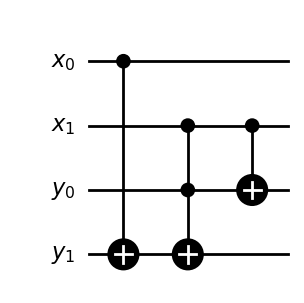

In [6]:
quantum_register = QuantumRegister(size=2, name="x")
ancilla_register = AncillaRegister(size=2, name="y")

F_adder = QuantumCircuit(quantum_register, ancilla_register, name="F(x) adder")

F_adder.cx(quantum_register[0], ancilla_register[1])
F_adder.ccx(quantum_register[1], ancilla_register[0], ancilla_register[1])
F_adder.cx(quantum_register[1], ancilla_register[0])

F_adder.draw(output="mpl", style="bw")

In [13]:
qr1= QuantumRegister(size=2, name="x")
qr2= QuantumRegister(size=2, name="y")
ar2= QuantumRegister(size=2, name="a")

qr3= QuantumRegister(size=2, name="o")
qc = QuantumCircuit(qr1)
qc.x(qr1)
compare_registers(2, qc, qr1, qr2, 0,qr3)
psi = Statevector(qc)
print(psi.probabilities())
qc.draw(output="mpl", style="bw")

NameError: name 'compare_registers' is not defined

In [37]:
dir(qc)

['__and__',
 '__class__',
 '__deepcopy__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iand__',
 '__init__',
 '__init_subclass__',
 '__ixor__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slotnames__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '__xor__',
 '_ancillas',
 '_append',
 '_append_standard_gate',
 '_base_name',
 '_builder_api',
 '_cast',
 '_cbit_argument_conversion',
 '_check_dups',
 '_clbit_indices',
 '_cls_instances',
 '_cls_prefix',
 '_control_flow_scopes',
 '_create_creg',
 '_create_qreg',
 '_current_scope',
 '_data',
 '_duration',
 '_from_circuit_data',
 '_increment_instances',
 '_layout',
 '_metadata',
 '_name_update',
 '_op_start_times',
 '_peek_previous_instruction_in_scope',
 '_pop_

In [38]:
qc.qubits

[<Qubit register=(2, "x"), index=0>, <Qubit register=(2, "x"), index=1>]